## Three-Level Atom Driven by DRAG Pulses

We consider a three-level atomic system. The transitions are governed by the Hamiltonian:

$
\hat{H} = \hbar(\hat{C} + \hat{V})
$

where the unperturbed part $\hat{C}$ and the interaction term $\hat{V}$ are given by:

$
\hat{C} = \omega_a S_1 + \omega_{b_1} S_5 + \omega_{b_2} S_9 + \Omega_1 \hat{a}_1^\dagger \hat{a}_1 + \Omega_2 \hat{a}_2^\dagger \hat{a}_2
$

$
\hat{V} = \lambda_1 (S^2 \hat{a}_1 + S^4 \hat{a}_1^\dagger) + \lambda_2 (S^3 \hat{a}_2 + S^7 \hat{a}_2^\dagger)
$

Here, $\hat{a}_i^\dagger$ and $\hat{a}_i$ are the bosonic creation and annihilation operators, $\lambda_i$ are the coupling constants, and $\Omega_i$ are the driving frequencies. The operators $S_i$ correspond to transitions between different atomic states.

In this setup, I have implemented the $X$, $Y$, $Z$ and Hadamard gates using DRAG-shaped pulses for the driving terms.


--- Starting DRAG Alpha Optimization for X-Gate ---


C:\Users\HP\anaconda3\lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


Optimization Complete. Best alpha found: -0.3979

--- Running Final Simulation with Optimized Alpha ---


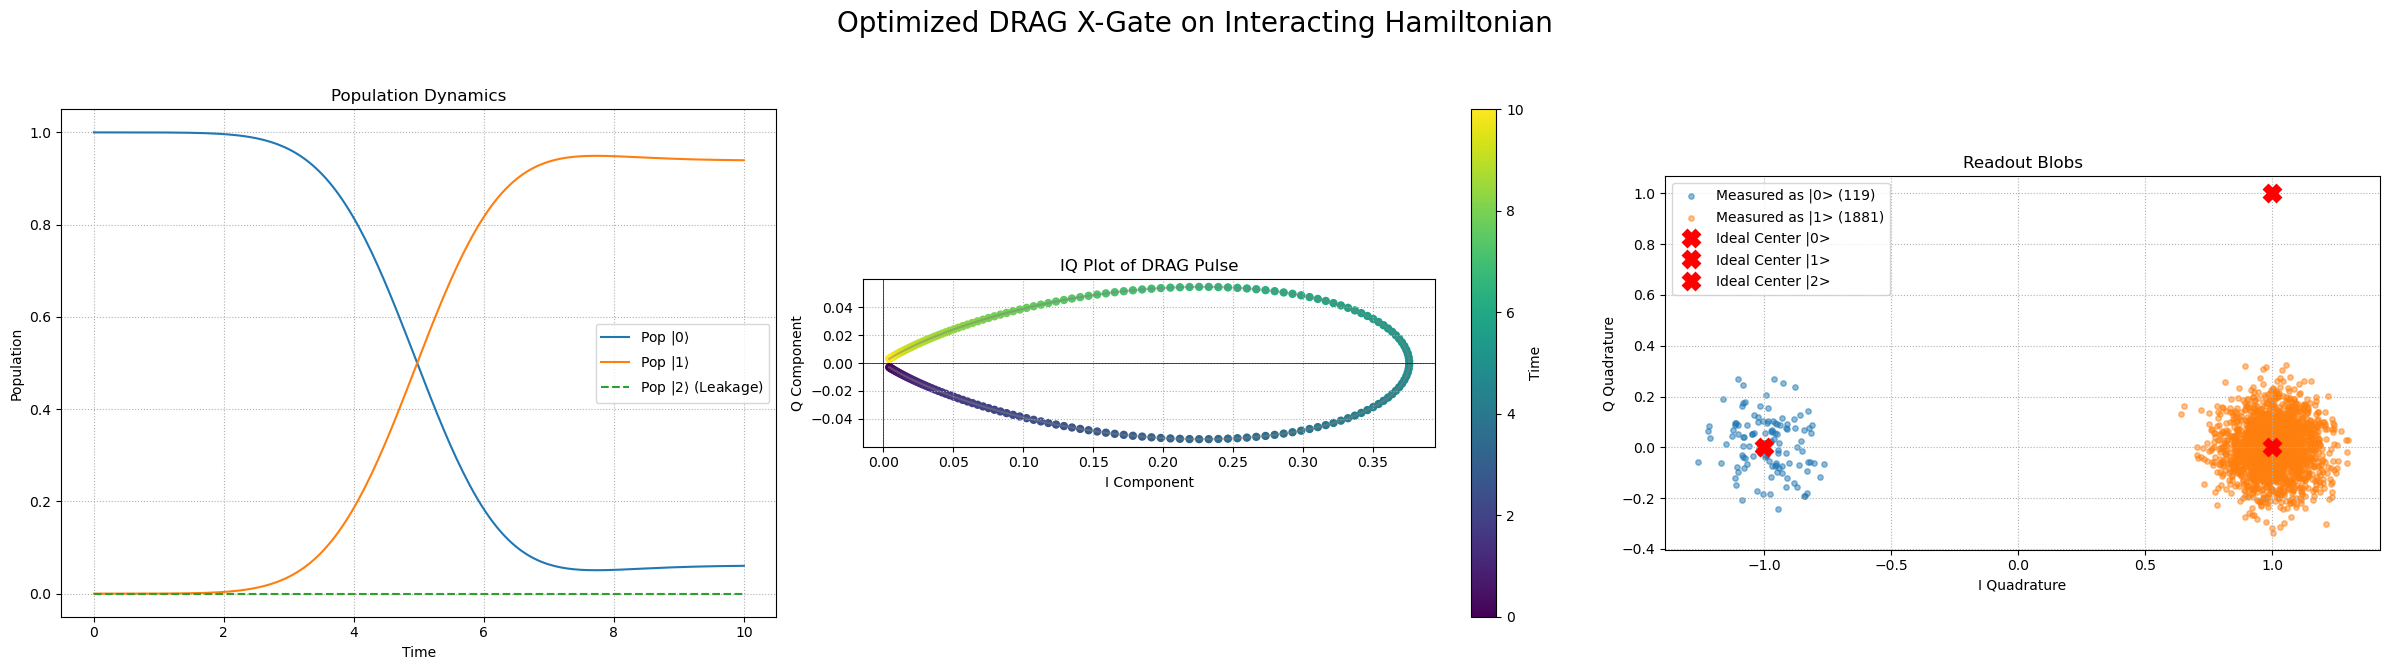

--- Final State Verification (Optimized DRAG X-Gate) ---
Final population of |0>: 0.0604
Final population of |1>: 0.9396
Final population of |2>: 0.000000
Final Fidelity: 0.939640


In [3]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from qutip import basis, tensor, destroy, qeye

# --- 1. Define System Parameters ---
N_atom = 3
N_field = 4
w0 = 5.0 * 2 * np.pi
w1 = 4.9 * 2 * np.pi
w2 = 5.2 * 2 * np.pi
Omega1 = 5.0 * 2 * np.pi
Omega2 = 4.99 * 2 * np.pi
lambda1 = 0.05 * 2 * np.pi
lambda2 = 0.05 * 2 * np.pi

# --- 2. Define ALL Operators---
a_bare = destroy(N_field)
sm02_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
sm12_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
sm02 = tensor(sm02_bare, qeye(N_field), qeye(N_field))
sm12 = tensor(sm12_bare, qeye(N_field), qeye(N_field))

sm01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
I_op_bare = sm01_bare + sm01_bare.dag()
Q_op_bare = -1j * (sm01_bare - sm01_bare.dag())

P0 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
P1 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
P2 = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))

I_op = tensor(I_op_bare, qeye(N_field), qeye(N_field))
Q_op = tensor(Q_op_bare, qeye(N_field), qeye(N_field))

# --- 3. Construct the FULL Static Hamiltonian (Unchanged) ---
H_static_full = w0*P0 + w1*P1 + w2*P2 + \
                Omega1*a1.dag()*a1 + Omega2*a2.dag()*a2 + \
                lambda1*(a1.dag()*sm02 + a1*sm02.dag()) + \
                lambda2*(a2.dag()*sm12 + a2*sm12.dag())

# --- 4. Define Pulse Parameters and Ideal State ---
gate_time = 10.0
sigma = gate_time / 6.0
t_peak = gate_time / 2.0
w_drive = w0 - w1
delta = (w2 - w1) - (w0 - w1)
alpha_theoretical = -1.0 / delta
pulse_amplitude = (np.pi / 2.0) / (sigma * np.sqrt(2 * np.pi))

psi0 = qt.tensor(basis(N_atom, 0), basis(N_field, 0), basis(N_field, 0))
ideal_final_state_bare = qt.basis(N_atom, 1) # Target for X-gate is |1>
ideal_final_state = qt.tensor(ideal_final_state_bare, qt.basis(N_field, 0), qt.basis(N_field, 0))

# --- 5. OPTIMIZE ALPHA PARAMETER FIRST ---
print("--- Starting DRAG Alpha Optimization for X-Gate ---")
alpha_range = np.linspace(alpha_theoretical * 0.5, alpha_theoretical * 1.5, 31)
fidelities = []
H_static_rot = H_static_full - w_drive * P0
options = qt.Options(store_states=True)
tlist_opt = np.linspace(0, gate_time, 100) 
for current_alpha in alpha_range:
    # --- Define pulse functions with the current alpha being tested ---
    def i_pulse_opt(t, args): return pulse_amplitude * np.exp(-(t - t_peak)**2 / (2 * sigma**2))
    def q_pulse_opt(t, args):
        i_env = i_pulse_opt(t, args)
        return current_alpha * (-(t - t_peak) / sigma**2) * i_env

    H_total_opt = [H_static_rot, [I_op, i_pulse_opt], [Q_op, q_pulse_opt]]
    res = qt.mesolve(H_total_opt, psi0, tlist_opt, c_ops=[], e_ops=[])
    
    fidelity = qt.fidelity(ideal_final_state, res.states[-1])**2
    fidelities.append(fidelity)

best_alpha = alpha_range[np.argmax(fidelities)]
print(f"Optimization Complete. Best alpha found: {best_alpha:.4f}\n")

# --- 6. RUN THE DEFINITIVE SIMULATION WITH THE BEST ALPHA ---
print("--- Running Final Simulation with Optimized Alpha ---")

# --- Redefine the final pulse shapes using the *best* alpha ---
alpha = best_alpha # Use the optimized value!
def i_pulse_envelope(t, args):
    return pulse_amplitude * np.exp(-(t - t_peak)**2 / (2 * sigma**2))
def q_pulse_envelope(t, args):
    envelope = i_pulse_envelope(t, args)
    return alpha * (-(t - t_peak) / sigma**2) * envelope

# --- Perform the final, high-resolution simulation for plotting ---
H_total_DRAG = [H_static_rot, [I_op, i_pulse_envelope], [Q_op, q_pulse_envelope]]
tlist = np.linspace(0, gate_time, 200)
e_ops = [P0, P1, P2]
result = qt.mesolve(H_total_DRAG, psi0, tlist, c_ops=[], e_ops=e_ops, options=options, args={})

# --- 7. PLOT THE OPTIMIZED RESULTS ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Optimized DRAG X-Gate on Interacting Hamiltonian', fontsize=20)

# Plot 1: Population Dynamics
ax1.plot(tlist, result.expect[0], label=r'Pop $|0\rangle$'); ax1.plot(tlist, result.expect[1], label=r'Pop $|1\rangle$')
ax1.plot(tlist, result.expect[2], label=r'Pop $|2\rangle$ (Leakage)', ls='--')
ax1.set_xlabel('Time'); ax1.set_ylabel('Population'); ax1.set_title('Population Dynamics')
ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_ylim([-0.05, 1.05])

# Plot 2: IQ Plot
i_vals = i_pulse_envelope(tlist, None); q_vals = q_pulse_envelope(tlist, None)
sc = ax2.scatter(i_vals, q_vals, c=tlist, cmap='viridis', s=25)
ax2.plot(i_vals, q_vals, color='grey', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax2); cbar.set_label('Time')
ax2.set_xlabel('I Component'); ax2.set_ylabel('Q Component'); ax2.set_title('IQ Plot of DRAG Pulse')
ax2.grid(True, linestyle=':'); ax2.set_aspect('equal', adjustable='box')
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)

# Plot 3: Readout Blobs
final_pops = np.array([e[-1] for e in result.expect]); final_pops /= np.sum(final_pops)
N_shots=2000; readout_noise_std=0.1
iq_centers = {0:[-1,0], 1:[1,0], 2:[1,1]}
measured_states = np.random.choice([0, 1, 2], size=N_shots, p=final_pops)
iq_data = np.array([np.random.normal(loc=iq_centers[s], scale=readout_noise_std) for s in measured_states])
for state in [0,1,2]:
    iq_s = iq_data[measured_states==state]
    if len(iq_s)>0: ax3.scatter(iq_s[:,0], iq_s[:,1], alpha=0.5, s=15, label=f'Measured as |{state}> ({len(iq_s)})')
for state, center in iq_centers.items():
    ax3.plot(center[0], center[1], 'X', c='r', ms=12, mew=2, label=f'Ideal Center |{state}>')
ax3.set_xlabel('I Quadrature'); ax3.set_ylabel('Q Quadrature'); ax3.set_title(f'Readout Blobs')
ax3.grid(True, linestyle=':'); ax3.set_aspect('equal', adjustable='box')
handles, labels = ax3.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax3.legend(by_label.values(), by_label.keys())

plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# --- 8. Final State Verification ---
print("--- Final State Verification (Optimized DRAG X-Gate) ---")
print(f"Final population of |0>: {final_pops[0]:.4f}")
print(f"Final population of |1>: {final_pops[1]:.4f}")
print(f"Final population of |2>: {final_pops[2]:.6f}")
fidelity_final = qt.fidelity(ideal_final_state, result.states[-1])**2
print(f"Final Fidelity: {fidelity_final:.6f}")

--- Starting DRAG Alpha Optimization for Y-Gate ---
Optimization Complete. Best alpha found: -0.3979

--- Running Final Simulation with Optimized Alpha ---


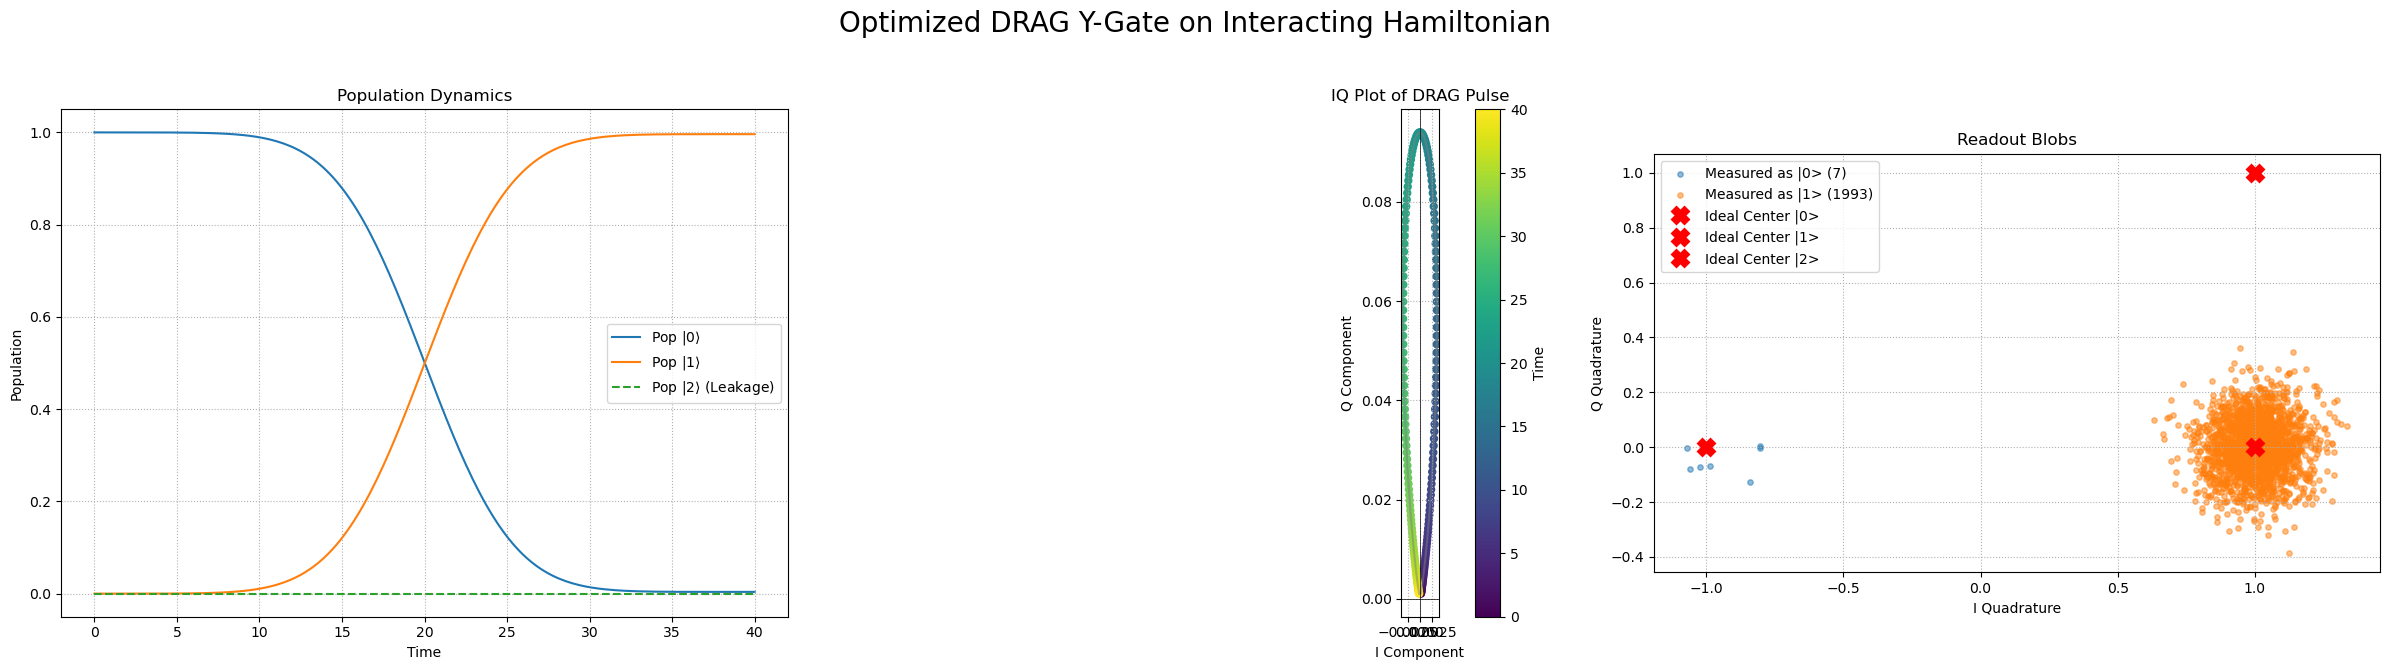

--- Final State Verification (Optimized DRAG Y-Gate) ---
Final population of |0>: 0.0039
Final population of |1>: 0.9961
Final population of |2>: 0.000000
Final Fidelity: 0.996125


In [55]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from qutip import basis, tensor, destroy, qeye

# --- 1. Define System Parameters ---
N_atom = 3
N_field = 4
w0 = 5.0 * 2 * np.pi
w1 = 4.9 * 2 * np.pi
w2 = 5.2 * 2 * np.pi
Omega1 = 5.0 * 2 * np.pi
Omega2 = 4.99 * 2 * np.pi
lambda1 = 0.05 * 2 * np.pi
lambda2 = 0.05 * 2 * np.pi

# --- 2. Define ALL Operators ---
a_bare = destroy(N_field)
sm02_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
sm12_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
sm02 = tensor(sm02_bare, qeye(N_field), qeye(N_field))
sm12 = tensor(sm12_bare, qeye(N_field), qeye(N_field))

sm01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
I_op_bare = sm01_bare + sm01_bare.dag()
Q_op_bare = -1j * (sm01_bare - sm01_bare.dag())

P0 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
P1 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
P2 = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))

I_op = tensor(I_op_bare, qeye(N_field), qeye(N_field))
Q_op = tensor(Q_op_bare, qeye(N_field), qeye(N_field))

# --- 3. Construct the FULL Static Hamiltonian  ---
H_static_full = w0*P0 + w1*P1 + w2*P2 + \
                Omega1*a1.dag()*a1 + Omega2*a2.dag()*a2 + \
                lambda1*(a1.dag()*sm02 + a1*sm02.dag()) + \
                lambda2*(a2.dag()*sm12 + a2*sm12.dag())

# --- 4. Define Pulse Parameters and Ideal State ---
gate_time = 40.0
sigma = gate_time / 6.0
t_peak = gate_time / 2.0
w_drive = w0 - w1
delta = (w2 - w1) - (w0 - w1)
alpha_theoretical = -1.0 / delta
pulse_amplitude = (np.pi / 2.0) / (sigma * np.sqrt(2 * np.pi))

psi0 = qt.tensor(basis(N_atom, 0), basis(N_field, 0), basis(N_field, 0))
# The target state for a Y-gate on |0> is i|1>
ideal_final_state_bare = 1j * qt.basis(N_atom, 1)
ideal_final_state = qt.tensor(ideal_final_state_bare, qt.basis(N_field, 0), qt.basis(N_field, 0))

# --- 5. OPTIMIZE ALPHA PARAMETER FIRST ---
print("--- Starting DRAG Alpha Optimization for Y-Gate ---")
alpha_range = np.linspace(alpha_theoretical * 0.5, alpha_theoretical * 1.5, 31)
fidelities = []
H_static_rot = H_static_full - w_drive * P0
options = qt.Options(store_states=True)
tlist_opt = np.linspace(0, gate_time, 100)

for current_alpha in alpha_range:
    # --- Define pulse functions for Y-gate with the current alpha ---
    def q_pulse_opt(t, args): return pulse_amplitude * np.exp(-(t - t_peak)**2 / (2 * sigma**2))
    def i_pulse_opt(t, args):
        q_env = q_pulse_opt(t, args)
        return -current_alpha * (-(t - t_peak) / sigma**2) * q_env

    H_total_opt = [H_static_rot, [I_op, i_pulse_opt], [Q_op, q_pulse_opt]]
    res = qt.mesolve(H_total_opt, psi0, tlist_opt, c_ops=[], e_ops=[], args={})
    
    fidelity = qt.fidelity(ideal_final_state, res.states[-1])**2
    fidelities.append(fidelity)

best_alpha = alpha_range[np.argmax(fidelities)]
print(f"Optimization Complete. Best alpha found: {best_alpha:.4f}\n")

# --- 6. RUN THE DEFINITIVE SIMULATION WITH THE BEST ALPHA ---
print("--- Running Final Simulation with Optimized Alpha ---")

# --- Redefine the final pulse shapes using the *best* alpha ---
alpha = best_alpha # Use the optimized value!
def q_pulse_envelope(t, args):
    """Gaussian envelope for the Q-channel (main Y-gate pulse)."""
    return pulse_amplitude * np.exp(-(t - t_peak)**2 / (2 * sigma**2))
def i_pulse_envelope(t, args):
    """Derivative envelope for the I-channel (DRAG correction for Y-gate)."""
    envelope_Q = q_pulse_envelope(t, args)
    return -alpha * (-(t - t_peak) / sigma**2) * envelope_Q

# --- Perform the final, high-resolution simulation for plotting ---
H_total_DRAG_Y = [H_static_rot, [I_op, i_pulse_envelope], [Q_op, q_pulse_envelope]]
tlist = np.linspace(0, gate_time, 200)
e_ops = [P0, P1, P2]
result = qt.mesolve(H_total_DRAG_Y, psi0, tlist, c_ops=[], e_ops=e_ops, options=options, args={})

# --- 7. PLOT THE OPTIMIZED RESULTS ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Optimized DRAG Y-Gate on Interacting Hamiltonian', fontsize=20)

# Plot 1: Population Dynamics
ax1.plot(tlist, result.expect[0], label=r'Pop $|0\rangle$'); ax1.plot(tlist, result.expect[1], label=r'Pop $|1\rangle$')
ax1.plot(tlist, result.expect[2], label=r'Pop $|2\rangle$ (Leakage)', ls='--')
ax1.set_xlabel('Time'); ax1.set_ylabel('Population'); ax1.set_title('Population Dynamics')
ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_ylim([-0.05, 1.05])

# Plot 2: IQ Plot
i_vals = i_pulse_envelope(tlist, None); q_vals = q_pulse_envelope(tlist, None)
sc = ax2.scatter(i_vals, q_vals, c=tlist, cmap='viridis', s=25)
ax2.plot(i_vals, q_vals, color='grey', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax2); cbar.set_label('Time')
ax2.set_xlabel('I Component'); ax2.set_ylabel('Q Component'); ax2.set_title('IQ Plot of DRAG Pulse')
ax2.grid(True, linestyle=':'); ax2.set_aspect('equal', adjustable='box')
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)

# Plot 3: Readout Blobs
final_pops = np.array([e[-1] for e in result.expect]); final_pops /= np.sum(final_pops)
N_shots=2000; readout_noise_std=0.1
iq_centers = {0:[-1,0], 1:[1,0], 2:[1,1]}
measured_states = np.random.choice([0, 1, 2], size=N_shots, p=final_pops)
iq_data = np.array([np.random.normal(loc=iq_centers[s], scale=readout_noise_std) for s in measured_states])
for state in [0,1,2]:
    iq_s = iq_data[measured_states==state]
    if len(iq_s)>0: ax3.scatter(iq_s[:,0], iq_s[:,1], alpha=0.5, s=15, label=f'Measured as |{state}> ({len(iq_s)})')
for state, center in iq_centers.items():
    ax3.plot(center[0], center[1], 'X', c='r', ms=12, mew=2, label=f'Ideal Center |{state}>')
ax3.set_xlabel('I Quadrature'); ax3.set_ylabel('Q Quadrature'); ax3.set_title(f'Readout Blobs')
ax3.grid(True, linestyle=':'); ax3.set_aspect('equal', adjustable='box')
handles, labels = ax3.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax3.legend(by_label.values(), by_label.keys())

plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# --- 8. Final State Verification ---
print("--- Final State Verification (Optimized DRAG Y-Gate) ---")
print(f"Final population of |0>: {final_pops[0]:.4f}")
print(f"Final population of |1>: {final_pops[1]:.4f}")
print(f"Final population of |2>: {final_pops[2]:.6f}")
fidelity_final = qt.fidelity(ideal_final_state, result.states[-1])**2
print(f"Final Fidelity: {fidelity_final:.6f}")

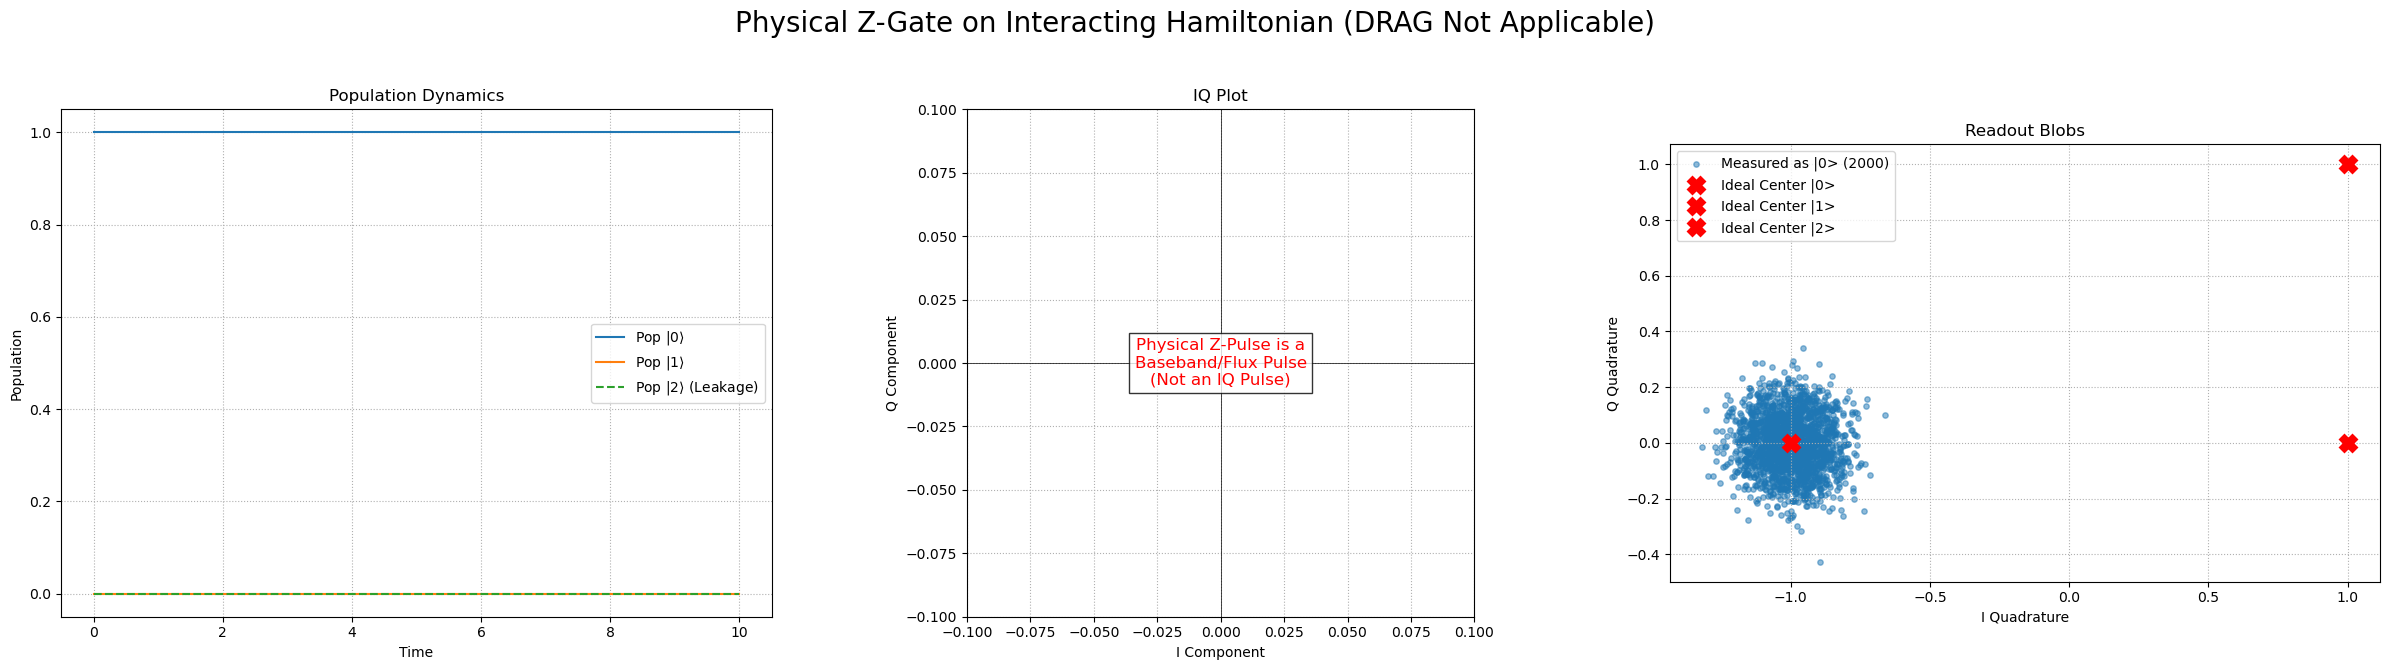

In [39]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from qutip import basis, tensor, destroy, qeye

# --- 1. Define System Parameters (Unchanged) ---
N_atom = 3
N_field = 4
w0 = 5.0 * 2 * np.pi
w1 = 4.9 * 2 * np.pi
w2 = 5.2 * 2 * np.pi
Omega1 = 5.0 * 2 * np.pi
Omega2 = 4.99 * 2 * np.pi
lambda1 = 0.05 * 2 * np.pi
lambda2 = 0.05 * 2 * np.pi

# --- 2. Define ALL Operators ---
a_bare = destroy(N_field)
sm02_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
sm12_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
sm02 = tensor(sm02_bare, qeye(N_field), qeye(N_field))
sm12 = tensor(sm12_bare, qeye(N_field), qeye(N_field))

# Operators for Drive and Projections
sigma_z_bare = basis(N_atom, 0).proj() - basis(N_atom, 1).proj()
P0 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
P1 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
P2 = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
sigma_z_op = tensor(sigma_z_bare, qeye(N_field), qeye(N_field))

# --- 3. Construct the FULL Static Hamiltonian (Unchanged) ---
H_static_full = w0*P0 + w1*P1 + w2*P2 + \
                Omega1*a1.dag()*a1 + Omega2*a2.dag()*a2 + \
                lambda1*(a1.dag()*sm02 + a1*sm02.dag()) + \
                lambda2*(a2.dag()*sm12 + a2*sm12.dag())

# --- 4. Define the Physical Z-Gate Pulse ---
# Note: DRAG is not applicable here.
z_gate_time = 10.0
# The condition for a Z-gate is that the integrated pulse strength is pi.
z_pulse_amplitude = np.pi / z_gate_time

def z_pulse_coeff(t, args):
    """Constant amplitude for the square Z-pulse."""
    return z_pulse_amplitude

# --- Total Hamiltonian for the physical Z-gate ---
H_total_Z = [H_static_full, [sigma_z_op, z_pulse_coeff]]

# --- 5. Run the Simulation ---
psi0 = qt.tensor(basis(N_atom, 0), basis(N_field, 0), basis(N_field, 0))
tlist = np.linspace(0, z_gate_time, 100)
e_ops = [P0, P1, P2]
options = qt.Options(store_states=True)
result = qt.mesolve(H_total_Z, psi0, tlist, c_ops=[], e_ops=e_ops, options=options, args={})

# --- 6. Plotting and Analysis ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Physical Z-Gate on Interacting Hamiltonian (DRAG Not Applicable)', fontsize=20)

# Plot 1: Population Dynamics
ax1.plot(tlist, result.expect[0], label=r'Pop $|0\rangle$'); ax1.plot(tlist, result.expect[1], label=r'Pop $|1\rangle$')
ax1.plot(tlist, result.expect[2], label=r'Pop $|2\rangle$ (Leakage)', ls='--')
ax1.set_xlabel('Time'); ax1.set_ylabel('Population'); ax1.set_title('Population Dynamics')
ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_ylim([-0.05, 1.05])

# Plot 2: IQ Plot
ax2.text(0, 0, 'Physical Z-Pulse is a\nBaseband/Flux Pulse\n(Not an IQ Pulse)', ha='center', va='center', color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
ax2.set_xlabel('I Component'); ax2.set_ylabel('Q Component'); ax2.set_title('IQ Plot')
ax2.grid(True, linestyle=':'); ax2.set_aspect('equal', adjustable='box')
ax2.set_xlim([-0.1, 0.1]); ax2.set_ylim([-0.1, 0.1])
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)

# Plot 3: Readout Blobs
final_pops = np.array([e[-1] for e in result.expect]); final_pops /= np.sum(final_pops)
N_shots=2000; readout_noise_std=0.1
iq_centers = {0:[-1,0], 1:[1,0], 2:[1,1]}
measured_states = np.random.choice([0, 1, 2], size=N_shots, p=final_pops)
iq_data = np.array([np.random.normal(loc=iq_centers[s], scale=readout_noise_std) for s in measured_states])
for state in [0,1,2]:
    iq_s = iq_data[measured_states==state]
    if len(iq_s)>0: ax3.scatter(iq_s[:,0], iq_s[:,1], alpha=0.5, s=15, label=f'Measured as |{state}> ({len(iq_s)})')
for state, center in iq_centers.items():
    ax3.plot(center[0], center[1], 'X', c='r', ms=12, mew=2, label=f'Ideal Center |{state}>')
ax3.set_xlabel('I Quadrature'); ax3.set_ylabel('Q Quadrature'); ax3.set_title(f'Readout Blobs')
ax3.grid(True, linestyle=':'); ax3.set_aspect('equal', adjustable='box')
handles, labels = ax3.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax3.legend(by_label.values(), by_label.keys())

plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

--- Starting DRAG Alpha Optimization ---
Optimization Complete. Best alpha found: -0.3979



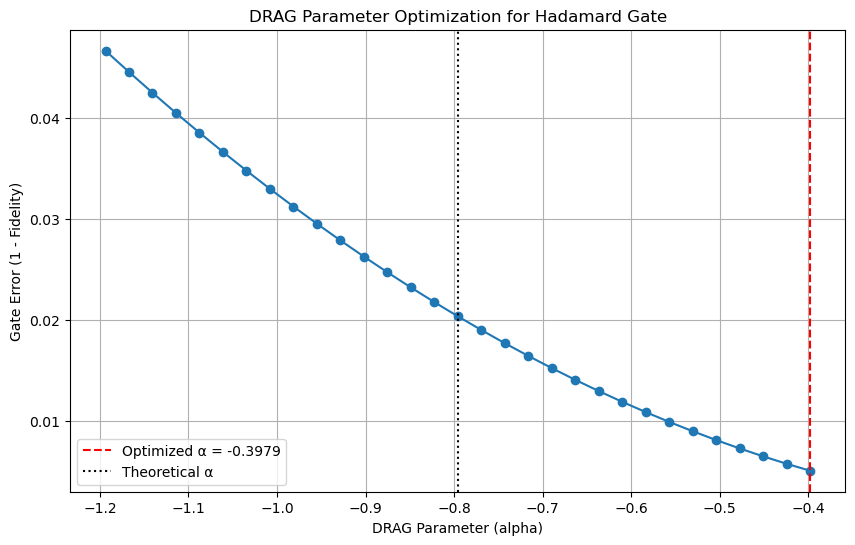

--- Running Final Simulation with Optimized Alpha ---


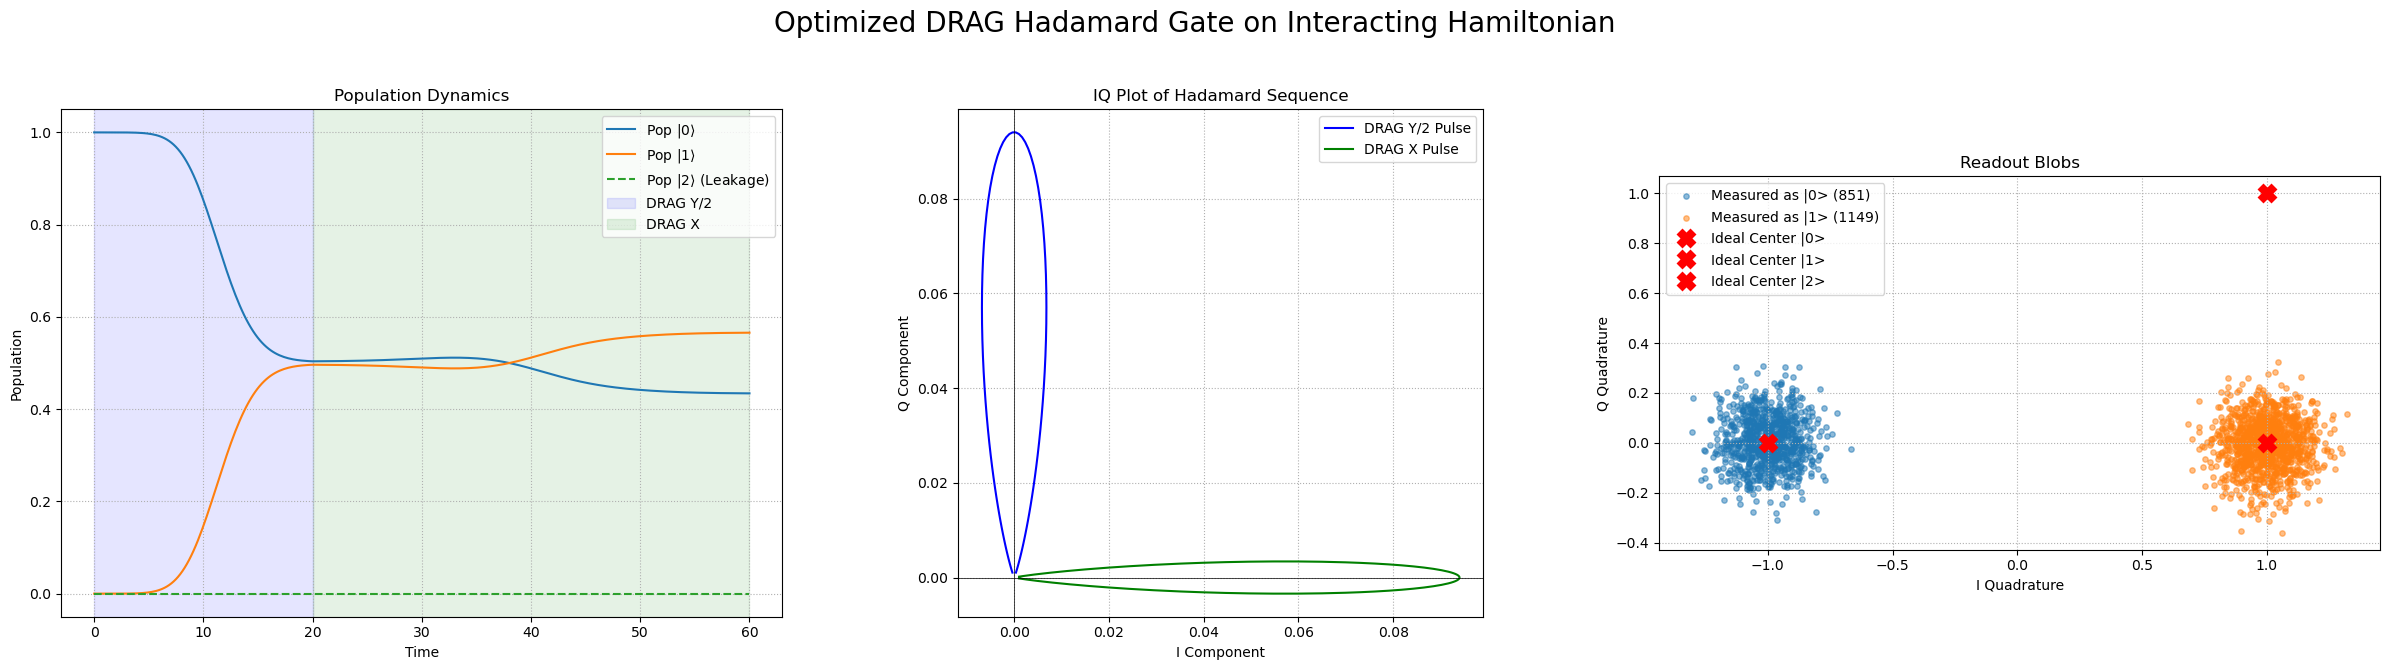

--- Final State Verification (Optimized Hadamard Gate) ---
Final population of |0>: 0.4343
Final population of |1>: 0.5657
Final population of |2>: 0.000000
Final Fidelity: 0.994939


In [57]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from qutip import basis, tensor, destroy, qeye

# --- 1. Define System Parameters ---
N_atom = 3
N_field = 4
w0 = 5.0 * 2 * np.pi
w1 = 4.9 * 2 * np.pi
w2 = 5.2 * 2 * np.pi
Omega1 = 5.0 * 2 * np.pi
Omega2 = 4.99 * 2 * np.pi
lambda1 = 0.05 * 2 * np.pi
lambda2 = 0.05 * 2 * np.pi

# --- 2. Define ALL Operators ---
a_bare = destroy(N_field)
sm02_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
sm12_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
sm02 = tensor(sm02_bare, qeye(N_field), qeye(N_field))
sm12 = tensor(sm12_bare, qeye(N_field), qeye(N_field))

sm01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
I_op_bare = sm01_bare + sm01_bare.dag()
Q_op_bare = -1j * (sm01_bare - sm01_bare.dag())

P0 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
P1 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
P2 = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))

I_op = tensor(I_op_bare, qeye(N_field), qeye(N_field))
Q_op = tensor(Q_op_bare, qeye(N_field), qeye(N_field))

# --- 3. Construct the FULL Static Hamiltonian  ---
H_static_full = w0*P0 + w1*P1 + w2*P2 + \
                Omega1*a1.dag()*a1 + Omega2*a2.dag()*a2 + \
                lambda1*(a1.dag()*sm02 + a1*sm02.dag()) + \
                lambda2*(a2.dag()*sm12 + a2*sm12.dag())

# --- 4. Define Pulse Parameters and Ideal State ---
w_drive = w0 - w1
delta = (w2 - w1) - (w0 - w1)
alpha_theoretical = -1.0 / delta

y2_gate_time = 20.0; y2_sigma = y2_gate_time / 6.0
y2_amplitude = (np.pi/2 / 2.0) / (y2_sigma * np.sqrt(2*np.pi))

x_gate_time = 40.0; x_sigma = x_gate_time / 6.0
x_amplitude = (np.pi / 2.0) / (x_sigma * np.sqrt(2*np.pi))

psi0 = qt.tensor(basis(N_atom, 0), basis(N_field, 0), basis(N_field, 0))
ideal_final_state_bare = (qt.basis(N_atom, 0) + qt.basis(N_atom, 1)).unit()
ideal_final_state = qt.tensor(ideal_final_state_bare, qt.basis(N_field, 0), qt.basis(N_field, 0))

# --- 5. OPTIMIZE ALPHA PARAMETER FIRST ---
print("--- Starting DRAG Alpha Optimization ---")
alpha_range = np.linspace(alpha_theoretical * 0.5, alpha_theoretical * 1.5, 31)
fidelities = []
H_static_rot = H_static_full - w_drive * P0
options = qt.Options(store_states=True)

for current_alpha in alpha_range:
    def y2_q_pulse_opt(t, args): return y2_amplitude * np.exp(-(t - args['t_peak'])**2 / (2 * y2_sigma**2))
    def y2_i_pulse_opt(t, args):
        q_env = y2_q_pulse_opt(t, args)
        return -current_alpha * (-(t - args['t_peak']) / y2_sigma**2) * q_env
    def x_i_pulse_opt(t, args): return x_amplitude * np.exp(-(t - args['t_peak'])**2 / (2 * x_sigma**2))
    def x_q_pulse_opt(t, args):
        i_env = x_i_pulse_opt(t, args)
        return current_alpha * (-(t - args['t_peak']) / x_sigma**2) * i_env

    t1 = np.linspace(0, y2_gate_time, 50)
    H_Y2 = [H_static_rot, [I_op, y2_i_pulse_opt], [Q_op, y2_q_pulse_opt]]
    res1 = qt.mesolve(H_Y2, psi0, t1, c_ops=[], e_ops=[], args={'t_peak': y2_gate_time/2.0})
    
    t2 = np.linspace(y2_gate_time, y2_gate_time + x_gate_time, 100)
    H_X = [H_static_rot, [I_op, x_i_pulse_opt], [Q_op, x_q_pulse_opt]]
    res2 = qt.mesolve(H_X, res1.states[-1], t2, c_ops=[], e_ops=[], args={'t_peak': y2_gate_time + x_gate_time/2.0})
    
    fidelity = qt.fidelity(ideal_final_state, res2.states[-1])**2
    fidelities.append(fidelity)

best_alpha = alpha_range[np.argmax(fidelities)]
print(f"Optimization Complete. Best alpha found: {best_alpha:.4f}\n")

# <<< NEW PLOT ADDED HERE TO VISUALIZE THE OPTIMIZATION >>>
fig_opt, ax_opt = plt.subplots(figsize=(10, 6))
ax_opt.plot(alpha_range, 1 - np.array(fidelities), 'o-')
ax_opt.axvline(best_alpha, color='r', linestyle='--', label=f'Optimized α = {best_alpha:.4f}')
ax_opt.axvline(alpha_theoretical, color='k', linestyle=':', label=f'Theoretical α')
ax_opt.set_xlabel('DRAG Parameter (alpha)')
ax_opt.set_ylabel('Gate Error (1 - Fidelity)')
ax_opt.set_title('DRAG Parameter Optimization for Hadamard Gate')
ax_opt.legend()
ax_opt.grid(True)
plt.show()

# --- 6. RUN THE DEFINITIVE SIMULATION WITH THE BEST ALPHA ---
print("--- Running Final Simulation with Optimized Alpha ---")
alpha = best_alpha
def y2_q_pulse(t, args): return y2_amplitude * np.exp(-(t-args['t_peak'])**2 / (2*y2_sigma**2))
def y2_i_pulse(t, args): return -alpha * (-(t-args['t_peak'])/y2_sigma**2) * y2_q_pulse(t, args)
def x_i_pulse(t, args): return x_amplitude * np.exp(-(t-args['t_peak'])**2 / (2*x_sigma**2))
def x_q_pulse(t, args): return alpha * (-(t-args['t_peak'])/x_sigma**2) * x_i_pulse(t, args)

e_ops = [P0, P1, P2]
tlist1 = np.linspace(0, y2_gate_time, 100)
H_Y2_final = [H_static_rot, [I_op, y2_i_pulse], [Q_op, y2_q_pulse]]
result1 = qt.mesolve(H_Y2_final, psi0, tlist1, c_ops=[], e_ops=e_ops, options=options, args={'t_peak': y2_gate_time/2.0})

psi_intermediate = result1.states[-1]
tlist2 = np.linspace(y2_gate_time, y2_gate_time + x_gate_time, 200)
H_X_final = [H_static_rot, [I_op, x_i_pulse], [Q_op, x_q_pulse]]
result2 = qt.mesolve(H_X_final, psi_intermediate, tlist2, c_ops=[], e_ops=e_ops, options=options, args={'t_peak': y2_gate_time + x_gate_time/2.0})

# --- 7. PLOT THE OPTIMIZED RESULTS ---
full_tlist = np.concatenate((result1.times, result2.times))
pop0 = np.concatenate((result1.expect[0], result2.expect[0]))
pop1 = np.concatenate((result1.expect[1], result2.expect[1]))
pop2 = np.concatenate((result1.expect[2], result2.expect[2]))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Optimized DRAG Hadamard Gate on Interacting Hamiltonian', fontsize=20)

# Plot 1: Population Dynamics
ax1.plot(full_tlist, pop0, label=r'Pop $|0\rangle$'); ax1.plot(full_tlist, pop1, label=r'Pop $|1\rangle$')
ax1.plot(full_tlist, pop2, label=r'Pop $|2\rangle$ (Leakage)', ls='--')
ax1.axvspan(0, y2_gate_time, color='blue', alpha=0.1, label='DRAG Y/2')
ax1.axvspan(y2_gate_time, y2_gate_time + x_gate_time, color='green', alpha=0.1, label='DRAG X')
ax1.set_xlabel('Time'); ax1.set_ylabel('Population'); ax1.set_title('Population Dynamics')
ax1.legend(); ax1.grid(True, linestyle=':'); ax1.set_ylim([-0.05, 1.05])

# Plot 2: IQ Plot
tlist1_plot = np.linspace(0, y2_gate_time, 100)
i_vals1 = y2_i_pulse(tlist1_plot, {'t_peak': y2_gate_time/2.0}); q_vals1 = y2_q_pulse(tlist1_plot, {'t_peak': y2_gate_time/2.0})
tlist2_plot = np.linspace(0, x_gate_time, 200)
i_vals2 = x_i_pulse(tlist2_plot, {'t_peak': x_gate_time/2.0}); q_vals2 = x_q_pulse(tlist2_plot, {'t_peak': x_gate_time/2.0})
ax2.plot(i_vals1, q_vals1, color='b', label='DRAG Y/2 Pulse')
ax2.plot(i_vals2, q_vals2, color='g', label='DRAG X Pulse')
ax2.set_xlabel('I Component'); ax2.set_ylabel('Q Component'); ax2.set_title('IQ Plot of Hadamard Sequence')
ax2.grid(True, linestyle=':'); ax2.set_aspect('equal', adjustable='box'); ax2.legend()
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)

# Plot 3: Readout Blobs
final_pops = np.array([pop0[-1], pop1[-1], pop2[-1]]); final_pops /= np.sum(final_pops)
N_shots=2000; readout_noise_std=0.1
iq_centers = {0:[-1,0], 1:[1,0], 2:[1,1]}
measured_states = np.random.choice([0, 1, 2], size=N_shots, p=final_pops)
iq_data = np.array([np.random.normal(loc=iq_centers[s], scale=readout_noise_std) for s in measured_states])
for state in [0,1,2]:
    iq_s = iq_data[measured_states==state]
    if len(iq_s)>0: ax3.scatter(iq_s[:,0], iq_s[:,1], alpha=0.5, s=15, label=f'Measured as |{state}> ({len(iq_s)})')
for state, center in iq_centers.items():
    ax3.plot(center[0], center[1], 'X', c='r', ms=12, mew=2, label=f'Ideal Center |{state}>')
ax3.set_xlabel('I Quadrature'); ax3.set_ylabel('Q Quadrature'); ax3.set_title(f'Readout Blobs')
ax3.grid(True, linestyle=':'); ax3.set_aspect('equal', adjustable='box')
handles, labels = ax3.get_legend_handles_labels(); by_label = dict(zip(labels, handles))
ax3.legend(by_label.values(), by_label.keys())

plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# --- 8. Final State Verification ---
print("--- Final State Verification (Optimized Hadamard Gate) ---")
print(f"Final population of |0>: {final_pops[0]:.4f}")
print(f"Final population of |1>: {final_pops[1]:.4f}")
print(f"Final population of |2>: {final_pops[2]:.6f}")
fidelity_final = qt.fidelity(ideal_final_state, result2.states[-1])**2
print(f"Final Fidelity: {fidelity_final:.6f}")